In [10]:
!pip install kagglehub

In [11]:
!pip install tensorflow numpy pandas matplotlib seaborn pillow scikit-learn tqdm

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, Conv2D, MaxPooling2D,
                                     BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator

import kagglehub

np.random.seed(42)
tf.random.set_seed(42)

print("Setup done ✅")

Setup done ✅


In [13]:
path = kagglehub.dataset_download("masoudnickparvar/white-blood-cells-dataset")

train_path = os.path.join(path, "Train")
test_path = os.path.join(path, "Test-A")

classes = ["Neutrophil", "Lymphocyte", "Monocyte", "Eosinophil", "Basophil"]

print("Dataset ready ✅")

Using Colab cache for faster access to the 'white-blood-cells-dataset' dataset.
Dataset ready ✅


In [14]:
img_size = 128
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

test_datagen = ImageDataGenerator(rescale=1./255)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print("Generators ready ✅")

Found 8142 images belonging to 5 classes.
Found 2033 images belonging to 5 classes.
Found 4339 images belonging to 5 classes.
Generators ready ✅


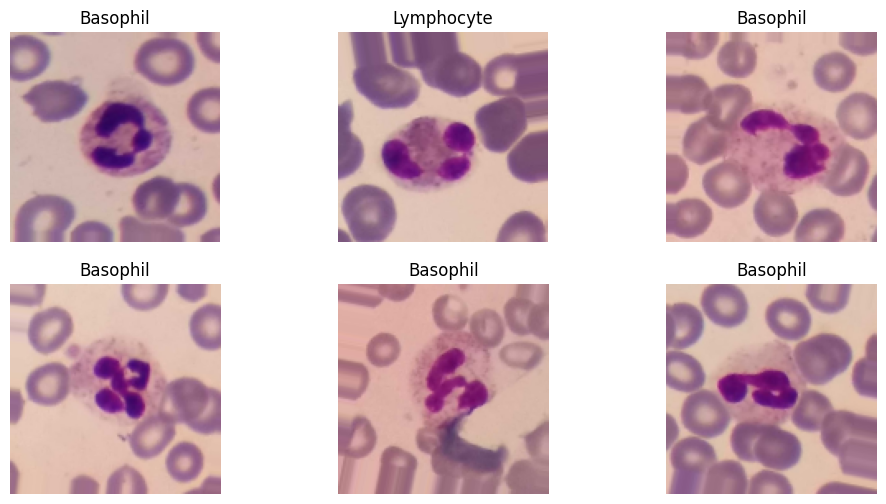

In [15]:
images, labels = next(train_generator)

plt.figure(figsize=(12,6))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(classes[np.argmax(labels[i])])
    plt.axis('off')
plt.show()

In [16]:
model = Sequential([

    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(),

    GlobalAveragePooling2D(),

    Dense(256, activation='relu'),
    Dropout(0.5),

    Dense(len(classes), activation='softmax')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 457,413 (1.74 MB)

 Trainable params: 456,453 (1.74 MB)

 Non-trainable params: 960 (3.75 KB)

In [17]:
callbacks = [
    ModelCheckpoint("best_cnn_model.keras", save_best_only=True, monitor='val_accuracy'),
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.2, patience=3)
]

In [18]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=30,
    callbacks=callbacks
)

Epoch 1/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 104s 361ms/step - accuracy: 0.8414 - loss: 0.4460 - val_accuracy: 0.4063 - val_loss: 1.2260 - learning_rate: 5.0000e-04
Epoch 2/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 65s 255ms/step - accuracy: 0.9428 - loss: 0.1736 - val_accuracy: 0.6695 - val_loss: 0.9340 - learning_rate: 5.0000e-04
Epoch 3/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 65s 254ms/step - accuracy: 0.9587 - loss: 0.1268 - val_accuracy: 0.7791 - val_loss: 0.7309 - learning_rate: 5.0000e-04
Epoch 4/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 67s 264ms/step - accuracy: 0.9667 - loss: 0.1050 - val_accuracy: 0.8180 - val_loss: 0.5884 - learning_rate: 5.0000e-04
Epoch 5/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 74s 292ms/step - accuracy: 0.9672 - loss: 0.1016 - val_accuracy: 0.6483 - val_loss: 1.4656 - learning_rate: 5.0000e-04
Epoch 6/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 66s 257ms/step - accuracy: 0.9700 - loss: 0.0866 - val_accuracy: 0.2381 - val_loss: 6.2678 - learning_rate: 5.0000e-04
Epoch 7/30
255/255 ━━━━━━━━━━━━━━━━━━━━ 73s 2

In [19]:
test_loss, test_acc = model.evaluate(test_generator)
print("Test Accuracy:", test_acc)

136/136 ━━━━━━━━━━━━━━━━━━━━ 19s 143ms/step - accuracy: 0.9670 - loss: 0.1038
Test Accuracy: 0.9670431017875671


136/136 ━━━━━━━━━━━━━━━━━━━━ 11s 79ms/step
              precision    recall  f1-score   support

  Neutrophil       1.00      0.99      0.99        89
  Lymphocyte       0.81      0.98      0.89       322
    Monocyte       0.97      0.99      0.98      1034
  Eosinophil       0.97      0.82      0.89       234
    Basophil       0.99      0.97      0.98      2660

    accuracy                           0.97      4339
   macro avg       0.95      0.95      0.95      4339
weighted avg       0.97      0.97      0.97      4339



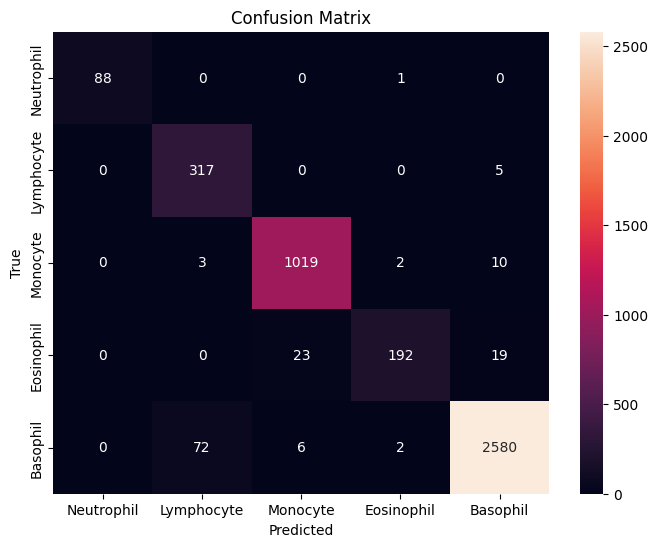

In [20]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

print(classification_report(y_true, y_pred_classes, target_names=classes))

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

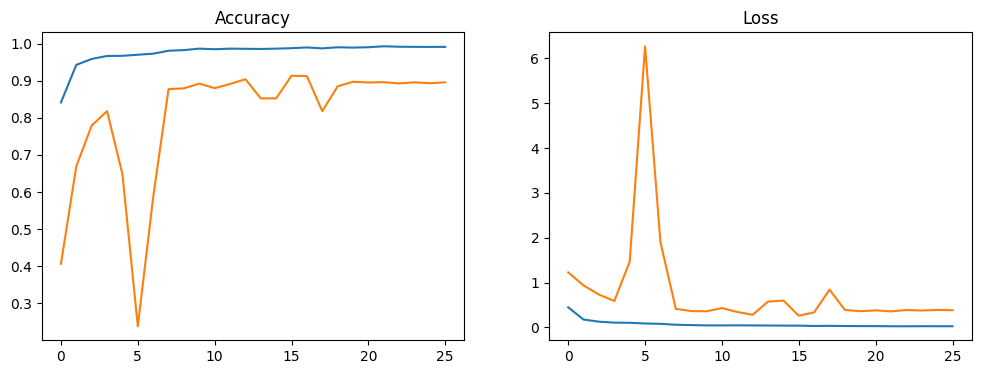

In [21]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")

plt.subplot(1,2,2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")

plt.show()

In [22]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
classes = list(train_generator.class_indices.keys())
print("Classes order:", classes)

def predict_image(img_path):
    img = Image.open(img_path).convert("RGB").resize((128,128))
    img_array = np.array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)
    pred = model.predict(img_array)
    cls_index = np.argmax(pred)

    print(f"Prediction: {classes[cls_index]} ({pred[0][cls_index]*100:.2f}%)")

    plt.imshow(img_array[0])
    plt.title(classes[cls_index])
    plt.axis('off')
    plt.show()

Classes order: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']


In [28]:
# Save the final model
model.save('wbc_classification_model.keras')
print("\nModel saved as 'wbc_classification_model.keras'")
from google.colab import files
files.download("wbc_classification_model.keras")


Model saved as 'wbc_classification_model.keras'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Classes: ['Basophil', 'Eosinophil', 'Lymphocyte', 'Monocyte', 'Neutrophil']

Upload an image (or click Cancel to stop)...


Saving 20190526_164800_1.jpg to 20190526_164800_1.jpg

Predicting 20190526_164800_1.jpg ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 872ms/step

Prediction: Basophil (100.00%)
All probabilities:
Basophil: 100.00%
Eosinophil: 0.00%
Lymphocyte: 0.00%
Monocyte: 0.00%
Neutrophil: 0.00%


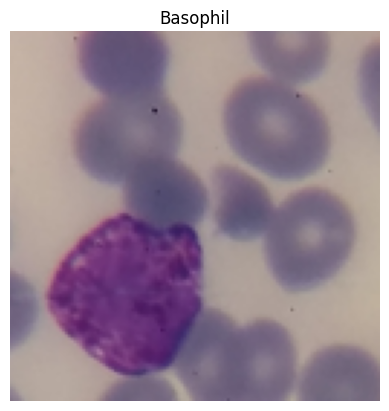


Upload an image (or click Cancel to stop)...


Saving 95-8-27-1_16_1.jpg to 95-8-27-1_16_1.jpg

Predicting 95-8-27-1_16_1.jpg ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step

Prediction: Eosinophil (98.54%)
All probabilities:
Basophil: 0.00%
Eosinophil: 98.54%
Lymphocyte: 0.01%
Monocyte: 0.01%
Neutrophil: 1.44%


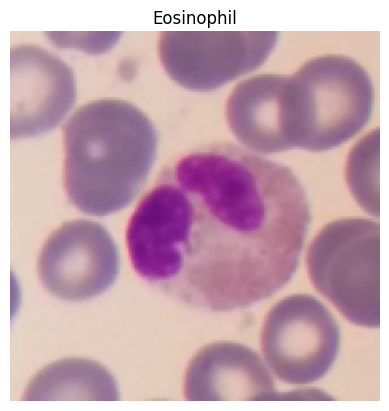


Upload an image (or click Cancel to stop)...


Saving 95-8-6-1_172_2.jpg to 95-8-6-1_172_2.jpg

Predicting 95-8-6-1_172_2.jpg ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Prediction: Lymphocyte (99.92%)
All probabilities:
Basophil: 0.00%
Eosinophil: 0.08%
Lymphocyte: 99.92%
Monocyte: 0.00%
Neutrophil: 0.00%


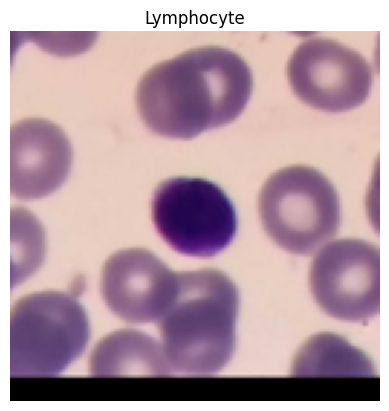


Upload an image (or click Cancel to stop)...


Saving 95-8-6-1_703_1.jpg to 95-8-6-1_703_1.jpg

Predicting 95-8-6-1_703_1.jpg ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

Prediction: Monocyte (95.80%)
All probabilities:
Basophil: 0.02%
Eosinophil: 0.05%
Lymphocyte: 1.40%
Monocyte: 95.80%
Neutrophil: 2.73%


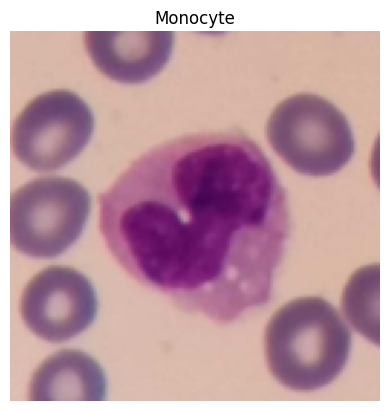


Upload an image (or click Cancel to stop)...


Saving 95-8-6-1_43_1.jpg to 95-8-6-1_43_1.jpg

Predicting 95-8-6-1_43_1.jpg ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step

Prediction: Neutrophil (100.00%)
All probabilities:
Basophil: 0.00%
Eosinophil: 0.00%
Lymphocyte: 0.00%
Monocyte: 0.00%
Neutrophil: 100.00%


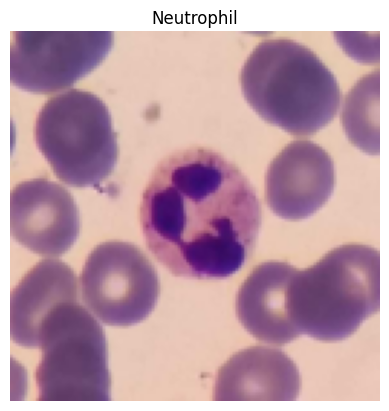


Upload an image (or click Cancel to stop)...


Saving 821.jpg to 821.jpg

Predicting 821.jpg ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Prediction: Eosinophil (93.09%)
All probabilities:
Basophil: 1.17%
Eosinophil: 93.09%
Lymphocyte: 5.46%
Monocyte: 0.25%
Neutrophil: 0.02%


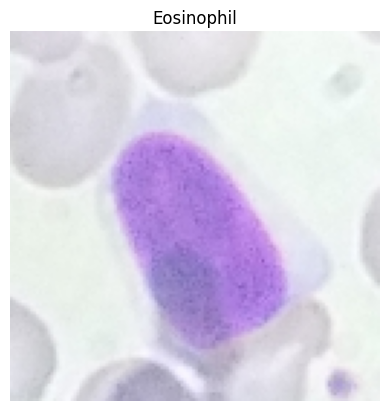


Upload an image (or click Cancel to stop)...


Saving 17.jpg to 17.jpg

Predicting 17.jpg ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step

Prediction: Basophil (99.97%)
All probabilities:
Basophil: 99.97%
Eosinophil: 0.00%
Lymphocyte: 0.00%
Monocyte: 0.00%
Neutrophil: 0.03%


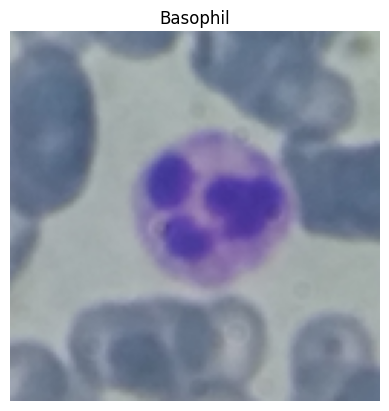


Upload an image (or click Cancel to stop)...


Saving 20190526_164053_0.jpg to 20190526_164053_0.jpg

Predicting 20190526_164053_0.jpg ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step

Prediction: Basophil (100.00%)
All probabilities:
Basophil: 100.00%
Eosinophil: 0.00%
Lymphocyte: 0.00%
Monocyte: 0.00%
Neutrophil: 0.00%


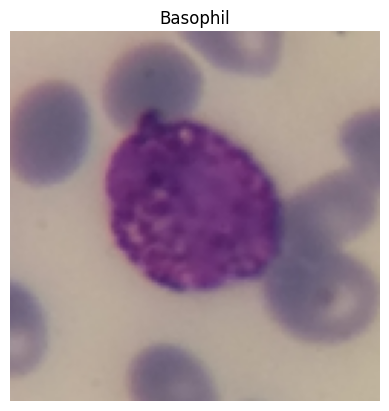


Upload an image (or click Cancel to stop)...


Saving 95-5-4-1_107_2.jpg to 95-5-4-1_107_2.jpg

Predicting 95-5-4-1_107_2.jpg ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

Prediction: Eosinophil (96.82%)
All probabilities:
Basophil: 0.04%
Eosinophil: 96.82%
Lymphocyte: 0.01%
Monocyte: 0.00%
Neutrophil: 3.13%


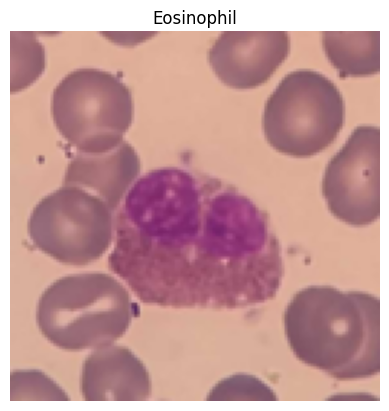


Upload an image (or click Cancel to stop)...


Saving 95-5-4-1_120_1.jpg to 95-5-4-1_120_1.jpg

Predicting 95-5-4-1_120_1.jpg ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step

Prediction: Monocyte (91.02%)
All probabilities:
Basophil: 6.15%
Eosinophil: 0.17%
Lymphocyte: 2.10%
Monocyte: 91.02%
Neutrophil: 0.55%


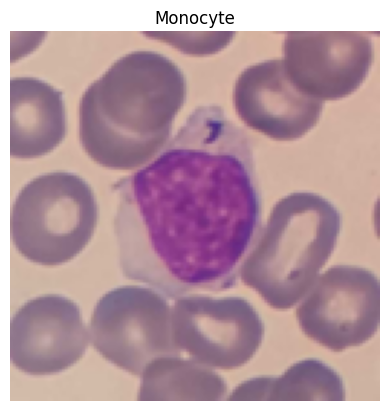


Upload an image (or click Cancel to stop)...


Saving 95-5-4-1_113_2.jpg to 95-5-4-1_113_2.jpg

Predicting 95-5-4-1_113_2.jpg ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

Prediction: Lymphocyte (93.41%)
All probabilities:
Basophil: 1.30%
Eosinophil: 0.18%
Lymphocyte: 93.41%
Monocyte: 4.33%
Neutrophil: 0.79%


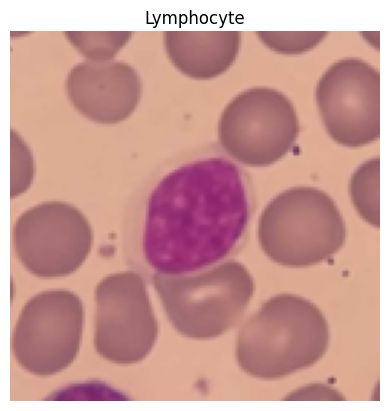


Upload an image (or click Cancel to stop)...


Saving 95-5-4-1_142_2.jpg to 95-5-4-1_142_2.jpg

Predicting 95-5-4-1_142_2.jpg ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

Prediction: Monocyte (99.72%)
All probabilities:
Basophil: 0.03%
Eosinophil: 0.05%
Lymphocyte: 0.15%
Monocyte: 99.72%
Neutrophil: 0.05%


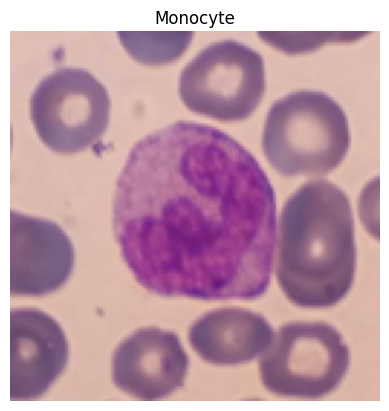


Upload an image (or click Cancel to stop)...


Saving 95-5-4-1_338_1.jpg to 95-5-4-1_338_1.jpg

Predicting 95-5-4-1_338_1.jpg ...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step

Prediction: Monocyte (48.30%)
All probabilities:
Basophil: 0.25%
Eosinophil: 7.69%
Lymphocyte: 11.07%
Monocyte: 48.30%
Neutrophil: 32.69%


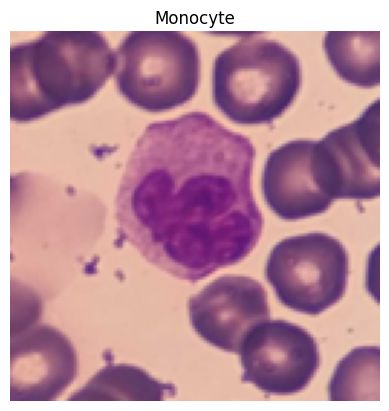


Upload an image (or click Cancel to stop)...


Done testing ✅


In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

classes = list(train_generator.class_indices.keys())
print("Classes:", classes)

def predict_image(img_path):
    img = Image.open(img_path).convert("RGB").resize((128,128))
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    cls_index = np.argmax(pred)

    print(f"\nPrediction: {classes[cls_index]} ({pred[0][cls_index]*100:.2f}%)")

    print("All probabilities:")
    for i, cls in enumerate(classes):
        print(f"{cls}: {pred[0][i]*100:.2f}%")

    plt.imshow(img)
    plt.title(classes[cls_index])
    plt.axis('off')
    plt.show()


while True:
    print("\nUpload an image (or click Cancel to stop)...")

    uploaded = files.upload()

    if len(uploaded) == 0:
        print("Done testing ✅")
        break

    for img_name in uploaded.keys():
        print(f"\nPredicting {img_name} ...")
        predict_image(img_name)